## Exploration with litemind for a structured query for regulatory programs

- last updated: 3/10/2025


- DESCRIBE the goals here:
    - 1) preprocess the structured input from the peak UMAP clusters for LLM queries (this should be scripted in the future)
    - 2) Perform structured "query" using litemind (ChatGPT API, etc.)

In [1]:
# define the openAI API key
import os
# # Set the API key BEFORE importing and using litemind
# os.environ["OPENAI_API_KEY"] = ""
# For OpenAI
openai_api_key = os.environ.get('OPENAI_API_KEY')
print(f"OpenAI API key available: {'Yes' if openai_api_key else 'No'}")

OpenAI API key available: No


In [2]:
# from dotenv import load_dotenv
# load_dotenv()  # load variables from .env file

# import os
# api_key = os.environ.get('OPENAI_API_KEY')
# print(f"OpenAI API key available: {'Yes' if openai_api_key else 'No'}")

OpenAI API key available: No


## Step 1. preprocess the structured input from the peak UMAP object
- scanpy/pandas to import and process the dataframe objects

### processing will be done in the following steps:
- First, import the peaks-by-pseudobulk matrix (with leiden clusters in adata.obs["leiden"]
- 1) context: a text blurb describing the data structure
Then, for each peak cluster, compute the following dataframes:
- 2) compute a vector for pseudobulk (averaging over peaks from each leiden cluster): a vector whose dimension is the celltype&timepoint
- 3) compute genes-by-counts (genes associated with each peak)
- 4) compute cluster-by-motif enrichment scores (computed by gimmemotifs maelstrom)



In [4]:
import scanpy as sc
import pandas as pd
import scipy
import numpy as np

In [14]:
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/peaks_by_celltype_timepoint_pseudobulked_hvp_50k_EDA2.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 50000 × 190
    obs: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibility_differentiating_neurons', 'accessibility_optic_cup', 'accessibility_hindbrain', 'accessibility_pha

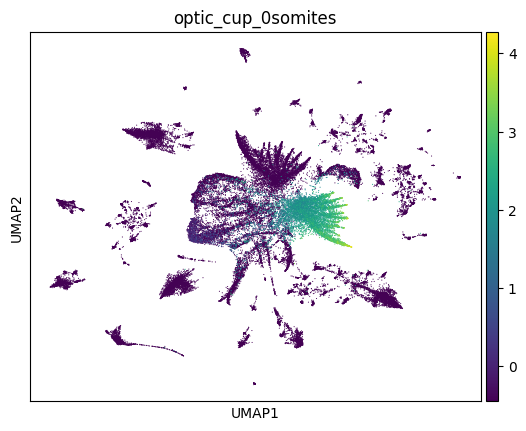

In [16]:
# sc.pl.umap(adata_peaks, color="optic_cup_0somites")

### 1) a pseudobulk vector for each leiden cluster

In [18]:
# # convert the counts layer to "log_norm"
# adata_peaks.X = adata_peaks.layers["log_norm"].copy()

# Get the unique leiden clusters
leiden_clusters = adata_peaks.obs["leiden"].unique()

# Create a pandas DataFrame to store the results
cluster_pseudobulk_df = pd.DataFrame(
    index=leiden_clusters,
    columns=adata_peaks.var_names
)

# Option 1: Using pandas groupby for vectorized operations
# This is often more memory-efficient for large datasets
pseudobulk_matrix = pd.DataFrame(
    adata_peaks.X.toarray() if scipy.sparse.issparse(adata_peaks.X) else adata_peaks.X,
    index=adata_peaks.obs["leiden"],
    columns=adata_peaks.var_names
)
cluster_pseudobulk_df = pseudobulk_matrix.groupby(level=0).mean()

cluster_pseudobulk_df.head()

/tmp/ipykernel_2743422/3301166611.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_pseudobulk_df = pseudobulk_matrix.groupby(level=0).mean()


,NMPs_0somites,NMPs_5somites,NMPs_10somites,NMPs_15somites,NMPs_20somites,NMPs_30somites,PSM_0somites,PSM_5somites,PSM_10somites,PSM_15somites,...,spinal_cord_10somites,spinal_cord_15somites,spinal_cord_20somites,spinal_cord_30somites,tail_bud_0somites,tail_bud_5somites,tail_bud_10somites,tail_bud_15somites,tail_bud_20somites,tail_bud_30somites
leiden,,,,,,,,,,,,,,,,,,,,,
0,-0.042674,-0.026494,-0.049006,-0.090401,-0.073813,-0.299912,-0.078162,-0.078325,-0.090554,-0.126974,...,-0.047297,-0.114400,-0.088570,-0.141402,-0.067527,-0.054556,-0.063299,-0.107699,-0.087247,2.197524
1,0.035284,0.046010,-0.002235,-0.049809,-0.039727,-0.293816,-0.033506,-0.028092,-0.062044,-0.097586,...,0.010526,-0.078016,-0.058746,-0.150582,-0.018583,-0.005020,-0.027844,-0.079826,-0.068812,-0.387729
2,-0.268797,-0.279984,-0.271460,-0.286117,-0.280323,-0.398425,-0.262179,-0.277867,-0.260515,-0.289354,...,-0.305610,-0.303393,-0.307715,-0.245691,-0.248753,-0.257145,-0.253153,-0.258948,-0.277770,-0.473970
3,0.910730,0.878431,0.753907,0.969648,0.722712,0.041741,0.519980,0.558695,0.438765,0.768198,...,2.567920,2.924409,3.062958,3.323708,0.504788,0.522609,0.419954,0.609762,0.564065,0.400853
4,-0.294563,-0.301070,-0.279448,-0.292834,-0.262063,2.316426,-0.276945,-0.292148,-0.278394,-0.302872,...,-0.330109,-0.315647,-0.318899,-0.256486,-0.262217,-0.277372,-0.259422,-0.267652,-0.267013,-0.474973


In [19]:
# save the count matrix as csv file
cluster_pseudobulk_df.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/leiden_by_pseudobulk.csv")

### 2) a dataframe of genes-by-counts for each leiden cluster

In [22]:
adata_peaks

AnnData object with n_obs × n_vars = 50000 × 190
    obs: 'count', 'percentile', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'dispersions', 'dispersions_norm', 'chrom', 'peak_type', 'manual_annotation_peaks', 'leiden_r1', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'distance_to_tss_binned', 'accessibility_notochord', 'accessibility_spinal_cord', 'accessibility_primordial_germ_cells', 'accessibility_NMPs', 'accessibility_neural', 'accessibility_neural_floor_plate', 'accessibility_neural_optic', 'accessibility_hatching_gland', 'accessibility_PSM', 'accessibility_neural_crest', 'accessibility_neural_telencephalon', 'accessibility_endoderm', 'accessibility_lateral_plate_mesoderm', 'accessibility_endocrine_pancreas', 'accessibility_epidermis', 'accessibility_neurons', 'accessibility_fast_muscle', 'accessibility_hemangioblasts', 'accessibility_differentiating_neurons', 'accessibility_optic_cup', 'accessibility_hindbrain', 'accessibility_pha

In [21]:
adata_peaks.obs["associated_gene"]

1-30119-30406                      eed
1-102102-102943                    f7l
1-128797-129190                    f7i
1-217215-217640                  tmco3
1-256849-257455                  grk1a
                             ...      
25-37374245-37375939           slc1a2b
25-37441836-37444212           slc10a3
25-37457158-37457567        FO834799.1
25-37471466-37471801        FO834799.2
25-37500598-37500859    CABZ01088346.1
Name: associated_gene, Length: 50000, dtype: category
Categories (15345, object): ['ABCA7', 'ABCC5', 'ACAP2', 'ACBD3', ..., 'zyg11', 'zyx', 'zzef1', 'zzz3']

In [23]:
# First, let's extract the relevant columns from adata_peaks.obs
peak_gene_data = adata_peaks.obs[["leiden", "associated_gene"]].copy()

# Some genes might have multiple entries, so we'll create a function to handle this
def process_gene_entries(gene_entry):
    if pd.isna(gene_entry):
        return []
    # Handle different possible formats of gene entries (comma-separated, list, etc.)
    if isinstance(gene_entry, str):
        return [g.strip() for g in gene_entry.split(',') if g.strip()]
    return [gene_entry]

# Create an expanded DataFrame with one row per peak-gene pair
peak_gene_pairs = []
for idx, row in peak_gene_data.iterrows():
    genes = process_gene_entries(row["associated_gene"])
    for gene in genes:
        peak_gene_pairs.append({
            "leiden": row["leiden"],
            "gene": gene
        })

# Convert to DataFrame
peak_gene_df = pd.DataFrame(peak_gene_pairs)

# If there are no valid gene associations, handle this case
if len(peak_gene_df) == 0:
    print("No gene associations found in the dataset")
    genes_by_counts = pd.DataFrame(index=adata_peaks.obs["leiden"].unique())
else:
    # Count occurrences of each gene in each leiden cluster
    gene_counts = peak_gene_df.groupby(["leiden", "gene"]).size().reset_index(name="count")
    
    # Pivot to create a leiden cluster x gene matrix
    genes_by_counts = gene_counts.pivot(index="leiden", columns="gene", values="count").fillna(0)
    
    # Ensure we have a row for every leiden cluster (even if no genes are associated)
    missing_clusters = set(adata_peaks.obs["leiden"].unique()) - set(genes_by_counts.index)
    for cluster in missing_clusters:
        genes_by_counts.loc[cluster] = 0
    
    # Sort the rows by leiden cluster
    genes_by_counts = genes_by_counts.loc[sorted(genes_by_counts.index)]

print(f"Created genes-by-counts matrix with shape: {genes_by_counts.shape}")

Created genes-by-counts matrix with shape: (38, 15345)


In [25]:
genes_by_counts.head()

gene,ABCA7,ABCC5,ACAP2,ACBD3,ACSF3,ACTC1,ACVR1C,ADAM12,ADAMTS7,ADGRL2,...,zranb3,zswim5,zswim6,zswim7,zswim8,zte38,zyg11,zyx,zzef1,zzz3
leiden,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
# First, create a dictionary that maps each leiden cluster to its associated genes
leiden_to_genes = {}

for leiden in genes_by_counts.index:
    # Get the genes that have counts > 0 for this leiden cluster
    genes_present = genes_by_counts.loc[leiden]
    genes_present = genes_present[genes_present > 0].index.tolist()
    
    # Store in dictionary
    leiden_to_genes[leiden] = genes_present

# If you need a DataFrame with comma-separated gene lists
leiden_gene_lists_df = pd.DataFrame({
    'leiden': list(leiden_to_genes.keys()),
    'genes': [','.join(genes) for genes in leiden_to_genes.values()]
})
leiden_gene_lists_df.set_index('leiden', inplace=True)

# Print example
print(leiden_gene_lists_df.head())

                                                    genes
leiden                                                   
0       ABCA7,ACTC1,ADGRL2,ADGRL3,AL590134.1,AL590150....
1       ABCA7,ABCC5,ACSF3,ADAM12,ADGRL2,ADGRL3,AL62725...
10      AL627126.1,AL831791.1,AL928866.2,AL929345.2,AL...
11      ACSF3,ACTC1,AL627258.1,AL772146.2,AL773558.1,A...
12      ACSF3,AL627088.2,AL627126.1,AL645691.2,AL84063...


In [39]:
genes_by_counts.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/leiden_by_assoc_genes.csv")

### 3) cluster-by-motifs (enrichment score)

In [42]:
clust_by_motifs = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/leiden_by_motifs_maelstrom.csv", index_col=0)
# Strip "z-score " from column names
clust_by_motifs.columns = clust_by_motifs.columns.str.replace('z-score ', '')
clust_by_motifs.head()

,1,7,22,0,11,2,17,3,8,20,...,29,13,32,16,38,18,35,36,37,34
GM.5.0.GATA.0013,-3.166926,-1.578836,1.575028,-2.476976,-3.600992,0.082494,-3.367772,-3.111129,-3.614202,-2.721471,...,0.219812,0.219812,-0.038468,0.164113,2.003150,0.366925,0.366925,-1.581857,-0.114942,-0.480372
GM.5.0.Mixed.0080,-1.776561,-0.856977,1.940311,-1.532555,-2.679053,1.072563,-2.360609,-2.595351,-2.713426,-1.841596,...,1.236990,1.202624,0.911772,1.142423,1.126530,1.236990,1.171292,-1.054165,0.839024,0.472187
GM.5.0.Forkhead.0043,-2.372250,-0.367497,2.685409,-1.616175,-2.382694,2.034423,-2.737328,-2.624996,-2.441437,-2.197579,...,2.201164,2.140962,1.914144,2.169832,2.810107,2.201164,2.427114,-0.697771,1.775140,1.367666
GM.5.0.C2H2_ZF.0262,-0.887447,0.395812,1.696593,-0.613692,-1.235281,1.410806,-0.369010,-1.238045,-1.064133,0.180706,...,1.382000,1.204701,0.915846,1.192858,0.205715,1.012979,0.068238,-0.242096,1.227729,0.840767
GM.5.0.Unknown.0033,3.221921,0.222173,-1.147747,2.181521,-0.345176,-0.450798,-1.990952,-1.703148,-1.538946,-2.860061,...,-1.351396,-0.846637,-1.644574,-1.248509,-1.574700,-1.573462,-0.385841,-1.963663,-0.339529,-0.963696


In [43]:
clust_by_motifs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/leiden_by_motifs_maelstrom.csv")


### 4) We need to import the TFs for each motif as a dictionary/df

In [7]:
info_motifs = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/info_GM_5.0_motif_factors.csv", index_col=0)
info_motifs.head()

,direct,indirect
motif,,
GM.5.0.Nuclear_receptor.0001,RORA,"RORB, Nr1d1, RORC, NR1D2, Rorc, Nr1d2, NR1D1, ..."
GM.5.0.IRF.0001,"IRF2, IRF1, IRF3","IRF2, IRF8, Six4, IRF3, Irf9, IRF4, IRF7, Six1..."
GM.5.0.ARID_BRIGHT.0001,"ARID3A, Arid3a","NP_032296.2, Tbpl2, NKX6-3, TBP, NKX6-1, HOXB9..."
GM.5.0.Homeodomain.0004,NaN,"IRX4, IRX3, IRX1, IRX6, Rhox11, Rhoxf1, Irx1, ..."
GM.5.0.Paired_box.0001,"Pax8, Pax5, PAX5","FOSL1, PAX1, Pax9, PAX5, Pax1, Pax6, PAX8, PAX..."


## generate a structured input
- a collection of csv files (or dataframes)
- query with structured output


In [29]:
from litemind import OpenAIApi
from litemind.agent.messages.message import Message
from litemind.agent.tools.toolset import ToolSet
from litemind.agent.tools.function_tool import FunctionTool
from litemind.apis.model_features import ModelFeatures
from litemind.agent.react.react_agent import ReActAgent
from pandas import DataFrame

# create an agent that can take pandas df as the input
# 5. Using the Agent with a Code Block
api = OpenAIApi()
agent = ReActAgent(api=api)
agent.append_system_message("You are a code generation assistant.")
response = agent(
    "Write a python function that returns the factorial of a number.",
)
print("Agent with Code Block:", response)

# Create a small table with pandas:
table = DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})

user_message = Message(role="user")
user_message.append_text("Can you describe what you see in the table?")
user_message.append_table(table)

# Run agent:
response = agent(user_message)

print("Agent with Table:", response)


# api = OpenAIApi()

# # Using the ReAct Agent with a Custom Tool
# # Create the ReAct agent
# react_agent = ReActAgent(api=api, toolset=toolset, temperature=0.0, max_reasoning_steps=3)

# # Add a system message
# react_agent.append_system_message(
#     "You are a helpful assistant that can answer questions and use tools."
# )

# # Ask a question
# response = react_agent("What is the current time?")

# # Print the response
# print("ReAct Agent Response:", response)

├╗ Calling ReAct Agent
│├╗ API and model:
││├ API: OpenAIApi
││├ Model: o3-mini
││┴« 81.30 microseconds
││
│├╗ Available tools
││┴« 0.72 microseconds
││
│├╗ Last message in conversation:
││├ *user*:
│││ Write a python function that returns the factorial of a number.
││┴« 75.82 microseconds
││
│├╗ ReAct Reasoning Loop
││├╗ Reasoning Step 1
│││├╗ Calling model
││││┴« 4.32 seconds
││││
│││├╗ Parsed response:
││││├ THINK: I need to provide a Python function that computes the factorial of a number. The factorial of n (denoted as n!) is the product of all positive integers less than or equal to n. I'll create a function that handles the base case (0! = 1) and computes the factorial iteratively.
││││├ DECIDE: FINAL_ANSWER
││││├ EXPLAIN: The following code defines a Python function 'factorial' which computes the factorial of a given number using a simple iterative approach. For input 0, it returns 1 directly. def factorial(n): if n < 0: raise ValueError("Factorial is not defined for negative n

## create a structured output (pydantic)


In [54]:
from pydantic import BaseModel
from typing import List, Optional

class ClusterSummary(BaseModel):
    cluster_id: int
    expression_highlights: str
    top_genes: List[str]
    motif_enrichment: str
    interpretation: str

class AllClustersSummary(BaseModel):
    clusters: List[ClusterSummary]

In [55]:
# (1) cluster_id-by-groups: e.g., expression across celltype-timepoint combos
df_clusters_groups = pd.DataFrame({
    'cluster_id': [1, 2, 3],
    'celltype_timepoint_1_expr': [10.2, 5.1, 0.0],
    'celltype_timepoint_2_expr': [8.3, 9.9, 1.2]
})

# (2) cluster_id-by-genes: e.g., gene counts or expression for relevant genes
df_clusters_genes = pd.DataFrame({
    'cluster_id': [1, 2, 3, 1, 2, 3],
    'gene': ['SOX2', 'SOX2', 'SOX2', 'MYC', 'MYC', 'MYC'],
    'count': [100, 80, 20, 200, 120, 5]
})

# (3) cluster_id-by-motifs: e.g., TF motif enrichment
df_clusters_motifs = pd.DataFrame({
    'cluster_id': [1, 2, 3],
    'motif': ['TF1_motif', 'TF2_motif', 'TF3_motif'],
    'enrichment_score': [3.2, 1.8, 0.5]
})

In [56]:
from litemind.agent.messages.message import Message
from litemind.apis.model_features import ModelFeatures

# Create the CombinedApi instance (automatically picks best LLM if you want):
api = OpenAIApi()

# We can optionally choose a model that supports text + table usage:
model_name = api.get_best_model([ModelFeatures.TextGeneration])

# Create a system message:
system_message = Message(role="system", text="""
You are a bioinformatics assistant. 
You will receive some structured data (in table form) about clusters of cells and their expression patterns, plus textual context.
Please provide an insightful cluster-by-cluster summary and interpret the data accordingly.
""")

# Create a user message to hold the data and instructions
user_message = Message(role="user")
user_message.append_text("""
We have three DataFrames describing clusters. 

1) cluster_id-by-groups: expression across celltype/timepoint combos
2) cluster_id-by-genes: gene counts per cluster
3) cluster_id-by-motifs: TF motif enrichment

Please analyze them and produce a structured summary for each cluster.
""")

# Append the three DataFrames as tables:
user_message.append_text("### clusters_vs_groups table:")
user_message.append_table(df_clusters_groups)

user_message.append_text("### clusters_vs_genes table:")
user_message.append_table(df_clusters_genes)

user_message.append_text("### clusters_vs_motifs table:")
user_message.append_table(df_clusters_motifs)

# user_message.append_text("### motifs information table:")
# user_message.append_table(df_motif_info)

DataFrame:    cluster_id      motif  enrichment_score
0           1  TF1_motif               3.2
1           2  TF2_motif               1.8
2           3  TF3_motif               0.5

In [57]:
from litemind.apis.callbacks.callback_manager import CallbackManager
from litemind.apis.callbacks.print_callbacks import PrintCallbacks

# (Optional) set up callbacks for debugging/printing
callback_manager = CallbackManager()
callback_manager.add_callback(PrintCallbacks(
    print_text_generation=True,
    print_text_streaming=True
))

# Create the API with callbacks if you want to see debug info
api = OpenAIApi(callback_manager=callback_manager)

# We send system + user messages, and request a structured response
response = api.generate_text(
    messages=[system_message, user_message],
    model_name=model_name,
    response_format=AllClustersSummary  # We'll get a structured object
)

# Now 'response' should be a list. 
# In LiteMind’s structured output usage, response[0] might hold the structured object:
all_clusters_summary: AllClustersSummary = response[0][-1].content

# Access the data
for cluster_info in all_clusters_summary.clusters:
    print(f"Cluster: {cluster_info.cluster_id}")
    print(f"Expression highlights: {cluster_info.expression_highlights}")
    print(f"Top Genes: {', '.join(cluster_info.top_genes)}")
    print(f"Motif Enrichment: {cluster_info.motif_enrichment}")
    print(f"Interpretation: {cluster_info.interpretation}\n")

├ Text Streaming: 
├ Text Streaming: {
├ Text Streaming:  
├ Text Streaming:  "
├ Text Streaming: clusters
├ Text Streaming: ":
├ Text Streaming:  [
├ Text Streaming:    
├ Text Streaming:  {
├ Text Streaming:      
├ Text Streaming:  "
├ Text Streaming: cluster
├ Text Streaming: _id
├ Text Streaming: ":
├ Text Streaming:  
├ Text Streaming: 1
├ Text Streaming: ,
├ Text Streaming:      
├ Text Streaming:  "
├ Text Streaming: expression
├ Text Streaming: _high
├ Text Streaming: lights
├ Text Streaming: ":
├ Text Streaming:  "
├ Text Streaming: High
├ Text Streaming:  overall
├ Text Streaming:  expression
├ Text Streaming:  with
├ Text Streaming:  slightly
├ Text Streaming:  higher
├ Text Streaming:  levels
├ Text Streaming:  in
├ Text Streaming:  cell
├ Text Streaming: type
├ Text Streaming: _time
├ Text Streaming: point
├ Text Streaming: _
├ Text Streaming: 1
├ Text Streaming:  (
├ Text Streaming: 10
├ Text Streaming: .
├ Text Streaming: 2
├ Text Streaming: )
├ Text Streaming:  compare

## Example prompting

In [85]:
# redefine the variable names
df_clusters_groups = cluster_pseudobulk_df
df_clusters_genes = genes_by_counts
df_clusters_motifs = clust_by_motifs
df_motif_info = info_motifs

In [73]:
# chunk the data for token size issues
import math

def chunk_df_rows(df, chunk_size=100):
    for i in range(0, len(df), chunk_size):
        yield df.iloc[i : i + chunk_size]

for idx, chunk in enumerate(chunk_df_rows(df_motif_info, chunk_size=100)):
    user_message.append_text(f"Motif info chunk {idx+1}:\n")
    user_message.append_table(chunk)

In [86]:
import tiktoken

def approximate_tokens(text: str, model_name: str = "gpt-3.5-turbo") -> int:
    """
    Returns the approximate number of tokens for a given text
    and model, using tiktoken.
    """
    encoder = tiktoken.encoding_for_model(model_name)
    return len(encoder.encode(text))

# Example usage:
csv_str = df_clusters_groups.to_csv(index=False)

num_tokens = approximate_tokens(csv_str, model_name="gpt-3.5-turbo")
byte_len = len(csv_str.encode("utf-8"))

print(f"Approx. {num_tokens} tokens, {byte_len} bytes in df_clusters_groups CSV.")

Approx. 66220 tokens, 151342 bytes in df_clusters_groups CSV.


In [89]:
# Example usage:
csv_str = leiden_gene_lists_df.to_csv(index=False)

num_tokens = approximate_tokens(csv_str, model_name="gpt-4")
byte_len = len(csv_str.encode("utf-8"))

print(f"Approx. {num_tokens} tokens, {byte_len} bytes in df_clusters_groups CSV.")

Approx. 185702 tokens, 308328 bytes in df_clusters_groups CSV.


In [84]:
df_clusters_genes

,cluster_id,gene,count
0,1,SOX2,100
1,2,SOX2,80
2,3,SOX2,20
3,1,MYC,200
4,2,MYC,120
5,3,MYC,5


In [81]:
# Example usage:
csv_str = motif_factor_df.to_csv(index=False)

num_tokens = approximate_tokens(csv_str, model_name="gpt-4")
byte_len = len(csv_str.encode("utf-8"))

print(f"Approx. {num_tokens} tokens, {byte_len} bytes in df_clusters_groups CSV.")

Approx. 628758 tokens, 633161 bytes in df_clusters_groups CSV.


In [92]:
# Example usage:
csv_str = df_motif_info.to_csv(index=False)

num_tokens = approximate_tokens(csv_str, model_name="gpt-4")
byte_len = len(csv_str.encode("utf-8"))

print(f"Approx. {num_tokens} tokens, {byte_len} bytes in df_clusters_groups CSV.")

Approx. 15555 tokens, 26060 bytes in df_clusters_groups CSV.


In [82]:
motif_factor_df

,9430076C15Rik,AC002126.6,AC012531.1,AC168977.1,AC189028.1,AC226150.2,AFP,AHR,AHRR,AIRE,...,Zscan4-ps2,Zscan4c,Zscan4f,arnt,cMyc,cebpa,mix-a,nMyc,p53,p63
motif,,,,,,,,,,,,,,,,,,,,,
GM.5.0.Nuclear_receptor.0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GM.5.0.IRF.0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GM.5.0.ARID_BRIGHT.0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GM.5.0.Homeodomain.0004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GM.5.0.Paired_box.0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GM.5.0.Unknown.0191,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GM.5.0.C2H2_ZF.0303,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GM.5.0.Homeodomain.0199,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
# 1) Fill missing values with empty strings, so we don't get NaNs
df_motif_info["direct"] = df_motif_info["direct"].fillna("")
df_motif_info["indirect"] = df_motif_info["indirect"].fillna("")

def parse_factor_list(factor_str: str):
    """
    Splits a comma-separated string into a set of factor names,
    stripping whitespace.
    """
    if not factor_str.strip():
        return set()
    return {f.strip() for f in factor_str.split(",") if f.strip()}

# 2) Build a dictionary mapping each motif -> set of all factors (direct + indirect)
motif_to_factors = {}
for motif, row in df_motif_info.iterrows():
    direct_factors = parse_factor_list(row["direct"])
    indirect_factors = parse_factor_list(row["indirect"])
    all_factors = direct_factors.union(indirect_factors)
    motif_to_factors[motif] = all_factors

# 3) Gather all factor names across all motifs
all_factor_names = sorted(set().union(*motif_to_factors.values()))

# 4) Create a new DataFrame with rows = motifs, columns = factor names
motif_factor_df = pd.DataFrame(0, index=df_motif_info.index, columns=all_factor_names)

# 5) Fill in 1 where factor is associated with that motif
for motif, factors in motif_to_factors.items():
    motif_factor_df.loc[motif, list(factors)] = 1

# Now you have a wide, binary matrix of shape:
# (num_motifs) x (total_unique_factors).
print(motif_factor_df.head(5))

                              9430076C15Rik  AC002126.6  AC012531.1  \
motif                                                                 
GM.5.0.Nuclear_receptor.0001              0           0           0   
GM.5.0.IRF.0001                           0           0           0   
GM.5.0.ARID_BRIGHT.0001                   0           0           0   
GM.5.0.Homeodomain.0004                   0           0           0   
GM.5.0.Paired_box.0001                    0           0           0   

                              AC168977.1  AC189028.1  AC226150.2  AFP  AHR  \
motif                                                                        
GM.5.0.Nuclear_receptor.0001           0           0           0    0    0   
GM.5.0.IRF.0001                        0           0           0    0    0   
GM.5.0.ARID_BRIGHT.0001                0           0           0    0    0   
GM.5.0.Homeodomain.0004                0           0           0    0    0   
GM.5.0.Paired_box.0001            

In [97]:
# Example usage:
for df in [df_clusters_groups, leiden_gene_lists_df, df_clusters_motifs, df_motif_info]:
    csv_str = df.to_csv(index=False)

    num_tokens = approximate_tokens(csv_str, model_name="gpt-4")
    byte_len = len(csv_str.encode("utf-8"))

    print(f"Approx. {num_tokens} tokens, {byte_len} bytes in df_clusters_groups CSV.")

Approx. 66220 tokens, 151342 bytes in df_clusters_groups CSV.
Approx. 185702 tokens, 308328 bytes in df_clusters_groups CSV.
Approx. 55201 tokens, 120891 bytes in df_clusters_groups CSV.
Approx. 15555 tokens, 26060 bytes in df_clusters_groups CSV.


In [95]:
import pandas as pd
from typing import List
from pydantic import BaseModel

# Suppose you have your four DataFrames already loaded:
#   genes_pseudobulk_df, genes_by_counts, clust_by_motifs, info_motifs
# For demonstration, we assume they're already defined.

# 1) Example data structure for final summary output
class ClusterSummary(BaseModel):
    cluster_id: str  # or int, depends on how your cluster IDs are labeled
    expression_highlights: str
    top_genes: List[str]
    motif_enrichment: str
    # Possibly you want to incorporate info_motifs (direct vs. indirect TF hits)
    motif_factor_insights: str

class AllClustersSummary(BaseModel):
    clusters: List[ClusterSummary]

# 2) Import LiteMind
# from litemind.apis.combined_api import CombinedApi
from litemind.agent.messages.message import Message
from litemind.apis.model_features import ModelFeatures

# 3) Create a system message with general guidance
system_message = Message(role="system", text="""
You are a bioinformatics assistant. 
You will receive four DataFrames describing:
1) Cluster-level pseudobulk gene expression,
2) Per-cluster gene list,
3) Motif enrichment scores per cluster,
4) Motif factor info linking motifs to TF names.
Please integrate these pieces of data to provide a per-cluster summary:
- Summarize expression highlights (which cell states/timepoints are most expressed),
- Identify important genes,
- Discuss enriched motifs and relevant transcription factors,
- Provide an overall interpretation for each cluster.
Make the summary concise and domain-relevant.
""")

# 4) Create a user message that appends the data + instructions
user_message = Message(role="user", text="""
We have four DataFrames. Please analyze them and produce a structured summary
for each cluster, referencing any key insights from these tables:
""")

# Append each DataFrame (assuming the `append_table` method is available 
# and your model or API supports table blocks):
# user_message.append_table(df_clusters_groups, name="genes_pseudobulk_df")
# user_message.append_table(df_clusters_genes, name="genes_by_counts")
# user_message.append_table(df_clusters_motifs, name="clust_by_motifs")
# user_message.append_table(df_motif_info, name="info_motifs")
user_message.append_text("### clusters_vs_groups table:")
user_message.append_table(df_clusters_groups)

user_message.append_text("### cluster vs gene_list table:")
user_message.append_table(leiden_gene_lists_df)
# user_message.append_table(df_clusters_genes)
# user_message.append_table(leiden_gene_lists_df)
# for idx, chunk in enumerate(chunk_df_rows(leiden_gene_lists_df, chunk_size=100)):
#     user_message.append_text(f"gene list chunk {idx+1}:\n")
#     user_message.append_table(chunk)

user_message.append_text("### clusters_vs_motifs table:")
user_message.append_table(df_clusters_motifs.transpose())

user_message.append_text("### motifs information table:")
# user_message.append_table(df_motif_info)
user_message.append_table(df_motif_info)
# for idx, chunk in enumerate(chunk_df_rows(df_motif_info, chunk_size=100)):
#     user_message.append_text(f"motif info chunk {idx+1}:\n")
#     user_message.append_table(chunk)

# 5) Instantiate the CombinedApi and choose a model that supports table input
api = OpenAIApi()
model_name = api.get_best_model([ModelFeatures.TextGeneration])

# 6) Make the request, asking for Pydantic-validated structured output
response = api.generate_text(
    messages=[system_message, user_message],
    model_name=model_name,
    response_format=AllClustersSummary  # We want a structured object parsed into AllClustersSummary
)

# 7) Access the structured results
all_clusters_summary: AllClustersSummary = response[0][-1].content
for cluster in all_clusters_summary.clusters:
    print(f"Cluster: {cluster.cluster_id}")
    print(f"Expression highlights: {cluster.expression_highlights}")
    print(f"Top Genes: {', '.join(cluster.top_genes)}")
    print(f"Motif Enrichment: {cluster.motif_enrichment}")
    print(f"Motif-Factor Insights: {cluster.motif_factor_insights}")
    print("----")


Traceback (most recent call last):
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/litemind/apis/providers/openai/openai_api.py", line 698, in generate_text
    with self.client.beta.chat.completions.stream(
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/lib/streaming/chat/_completions.py", line 148, in __enter__
    raw_stream = self.__api_request()
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/_utils/_utils.py", line 279, in wrapper
    return func(*args, **kwargs)
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/resources/chat/completions/completions.py", line 879, in create
    return self._post(
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/_base_client.py", line 1296, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
  File "/home/yang

APIError: OpenAI generate text error: Error code: 400 - {'error': {'message': "Invalid 'messages[1].content[4].text': string too long. Expected a string with maximum length 1048576, but got a string with length 1645616 instead.", 'type': 'invalid_request_error', 'param': 'messages[1].content[4].text', 'code': 'string_above_max_length'}}

In [98]:
import pandas as pd
from typing import List
from pydantic import BaseModel

# LiteMind / OpenAI API imports
from litemind.agent.messages.message import Message
from litemind.apis.providers.openai.openai_api import OpenAIApi
from litemind.apis.model_features import ModelFeatures

# tiktoken for token estimation
import tiktoken

#########################################################
# Function to estimate tokens for a given text + model
#########################################################
def approximate_tokens(text: str, model_name: str = "gpt-3.5-turbo") -> int:
    """
    Returns an approximate number of tokens for 'text'
    using the specified model's tokenizer via tiktoken.
    """
    encoder = tiktoken.encoding_for_model(model_name)
    return len(encoder.encode(text))

#########################################################
# Example Pydantic model for structured response
#########################################################
class ClusterSummary(BaseModel):
    cluster_id: str  # or int, depends on your data
    expression_highlights: str
    top_genes: List[str]
    motif_enrichment: str
    motif_factor_insights: str

class AllClustersSummary(BaseModel):
    clusters: List[ClusterSummary]

#########################################################
# Assume the following DataFrames are loaded:
#   1) df_clusters_groups
#   2) leiden_gene_lists_df (or df_clusters_genes)
#   3) df_clusters_motifs
#   4) df_motif_info
#
# Replace with your actual data-loading code.
#########################################################
# For demonstration, let's pretend these are loaded:
# df_clusters_groups = ...
# leiden_gene_lists_df = ...
# df_clusters_motifs = ...
# df_motif_info = ...

#########################################################
# 1) Convert each DataFrame to CSV and measure token usage
#########################################################
model_for_estimate = "gpt-3.5-turbo"  # or whichever model you plan to use

def df_token_estimate(df: pd.DataFrame, df_name: str):
    csv_str = df.to_csv(index=False)
    num_tokens = approximate_tokens(csv_str, model_name=model_for_estimate)
    print(f"DataFrame '{df_name}' => ~{num_tokens} tokens (CSV).")
    return csv_str, num_tokens

# Example usage:
csv_clusters_groups, tk_clusters_groups = df_token_estimate(df_clusters_groups, "df_clusters_groups")
csv_genes, tk_genes = df_token_estimate(leiden_gene_lists_df, "leiden_gene_lists_df")
csv_motifs, tk_motifs = df_token_estimate(df_clusters_motifs, "df_clusters_motifs")
csv_motif_info, tk_motif_info = df_token_estimate(df_motif_info, "df_motif_info")

#########################################################
# 2) Print a quick summary of token usage
#########################################################
total_tokens = tk_clusters_groups + tk_genes + tk_motifs + tk_motif_info
print("\nSummary of approximate token usage (CSV forms):")
print(f"  df_clusters_groups: {tk_clusters_groups}")
print(f"  leiden_gene_lists_df: {tk_genes}")
print(f"  df_clusters_motifs: {tk_motifs}")
print(f"  df_motif_info: {tk_motif_info}")
print(f"  TOTAL: {total_tokens} tokens")

#########################################################
# 3) If each DataFrame is small enough, you can append
#    them directly. Otherwise, chunk or summarize.
#########################################################
# Example of building messages and sending to OpenAI
system_message = Message(
    role="system",
    text="""
You are a bioinformatics assistant. You will receive multiple DataFrames...
Please provide a structured cluster-by-cluster summary.
"""
)

user_message = Message(
    role="user",
    text="We have four DataFrames. Please analyze them and produce a structured summary:"
)

# Suppose the CSV is not too large:
user_message.append_text("### clusters_vs_groups table:")
user_message.append_text(csv_clusters_groups)  # or user_message.append_table if you have it

user_message.append_text("### cluster vs gene_list table:")
user_message.append_text(csv_genes)

user_message.append_text("### clusters_vs_motifs table:")
user_message.append_text(csv_motifs)

user_message.append_text("### motifs information table:")
user_message.append_text(csv_motif_info)

#########################################################
# 4) Now call the OpenAI API if under limits
#########################################################
api = OpenAIApi()  # from litemind.apis.providers.openai.openai_api import OpenAIApi
model_name = api.get_best_model([ModelFeatures.TextGeneration])  # or "gpt-3.5-turbo"

# If the entire text is under the single-message ~1 MB limit and within total token context,
# you can attempt the generation:
response = api.generate_text(
    messages=[system_message, user_message],
    model_name=model_name,
    response_format=AllClustersSummary
)

all_clusters_summary: AllClustersSummary = response[0][-1].content
for cluster in all_clusters_summary.clusters:
    print(f"Cluster: {cluster.cluster_id}")
    print(f"Expression highlights: {cluster.expression_highlights}")
    print(f"Top Genes: {', '.join(cluster.top_genes)}")
    print(f"Motif Enrichment: {cluster.motif_enrichment}")
    print(f"Motif-Factor Insights: {cluster.motif_factor_insights}")
    print("----")


DataFrame 'df_clusters_groups' => ~66220 tokens (CSV).
DataFrame 'leiden_gene_lists_df' => ~185702 tokens (CSV).
DataFrame 'df_clusters_motifs' => ~55201 tokens (CSV).
DataFrame 'df_motif_info' => ~15555 tokens (CSV).

Summary of approximate token usage (CSV forms):
  df_clusters_groups: 66220
  leiden_gene_lists_df: 185702
  df_clusters_motifs: 55201
  df_motif_info: 15555
  TOTAL: 322678 tokens


Traceback (most recent call last):
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/litemind/apis/providers/openai/openai_api.py", line 698, in generate_text
    with self.client.beta.chat.completions.stream(
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/lib/streaming/chat/_completions.py", line 148, in __enter__
    raw_stream = self.__api_request()
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/_utils/_utils.py", line 279, in wrapper
    return func(*args, **kwargs)
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/resources/chat/completions/completions.py", line 879, in create
    return self._post(
  File "/home/yang-joon.kim/.conda/envs/litemind_env/lib/python3.9/site-packages/openai/_base_client.py", line 1296, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
  File "/home/yang

APIError: OpenAI generate text error: Error code: 400 - {'error': {'message': "This model's maximum context length is 200000 tokens. However, your messages resulted in 321879 tokens (including 151 in the response_format schemas.). Please reduce the length of the messages or schemas.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}